# 05 — EDA Blocco 1: Panoramica e trend temporali

**Fase PACE**: Analyze  
**Obiettivo**: rispondere alle domande 1.1–1.5 delle research questions. 
Identificare i crimini più frequenti, analizzare i trend annuali, 
i pattern stagionali e le distribuzioni per fascia oraria e giorno 
della settimana.

**Input**: `data/processed/crimes_features.parquet`

**Domande a cui rispondiamo**:
- Q1.1 — Top 5 crimini più frequenti e trend anno per anno
- Q1.2 — Top 5 crimini contro la persona vs contro la proprietà e trend
- Q1.3 — Categorie con maggior crescita e decrescita YoY
- Q1.4 — Pattern stagionali per tipo di crimine
- Q1.5 — Fasce orarie e giorni della settimana per area LAPD

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_info_columns', 200)

df = pd.read_parquet('../../data/processed/crimes_features.parquet')
df.shape

(3079424, 32)

## 2. Q1.1 — Top 5 crimini più frequenti

Identifichiamo i 5 reati con il maggior numero di occorrenze nell'intero 
dataset (2010–2024), poi ne visualizziamo il trend anno per anno.

In [4]:
df['Crm Cd Desc'].value_counts()

Crm Cd Desc
VEHICLE - STOLEN                                            271661
BATTERY - SIMPLE ASSAULT                                    261872
BURGLARY FROM VEHICLE                                       222893
BURGLARY                                                    202205
THEFT PLAIN - PETTY ($950 & UNDER)                          200671
THEFT OF IDENTITY                                           187848
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)     168227
INTIMATE PARTNER - SIMPLE ASSAULT                           158201
ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT              144371
THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)             127823
ROBBERY                                                     114396
VANDALISM - MISDEAMEANOR ($399 OR UNDER)                    114163
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD    108460
SHOPLIFTING - PETTY THEFT ($950 & UNDER)                     78009
CRIMINAL THREATS - NO WEAPON DISPLAYED            

In [5]:
top5_filter = ['VEHICLE - STOLEN', 'BATTERY - SIMPLE ASSAULT', 'BURGLARY FROM VEHICLE', 'BURGLARY', 'THEFT PLAIN - PETTY ($950 & UNDER)']
top5_df = df[df['Crm Cd Desc'].isin(top5_filter)]

top5_grouped = top5_df.groupby(
    ['year', 'Crm Cd Desc']).size().reset_index(name='count')

top5_grouped.head(5)

,year,Crm Cd Desc,count
0,2010,BATTERY - SIMPLE ASSAULT,20527
1,2010,BURGLARY,16086
2,2010,BURGLARY FROM VEHICLE,17705
3,2010,THEFT PLAIN - PETTY ($950 & UNDER),11139
4,2010,VEHICLE - STOLEN,16684


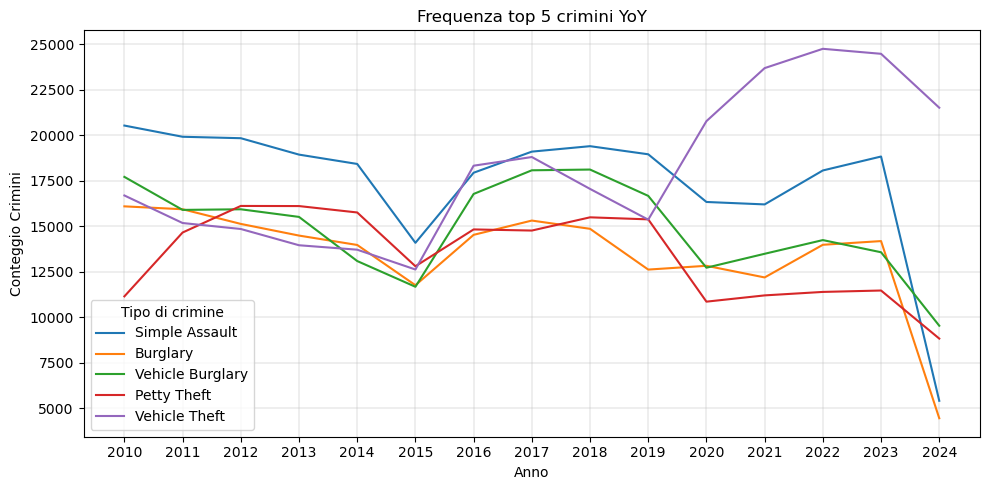

In [6]:
short_names = {
    'VEHICLE - STOLEN': 'Vehicle Theft',
    'BATTERY - SIMPLE ASSAULT': 'Simple Assault',
    'BURGLARY FROM VEHICLE': 'Vehicle Burglary',
    'BURGLARY': 'Burglary',
    'THEFT PLAIN - PETTY ($950 & UNDER)': 'Petty Theft'
}

top5_grouped['crime_short'] = top5_grouped['Crm Cd Desc'].map(short_names)

fig = plt.subplots(figsize=(10,5))
sns.lineplot(
    x = top5_grouped['year'],
    y = top5_grouped['count'],
    hue = top5_grouped['crime_short']
)

plt.legend(title='Tipo di crimine')
plt.title('Frequenza top 5 crimini YoY')
plt.xlabel('Anno')
plt.ylabel('Conteggio Crimini')
plt.grid(
    linewidth = 0.3
)
plt.xticks(range(2010, 2025))
plt.savefig('../../outputs/top5_crimes_trend.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

### Osservazioni Q1.1

- **Crollo 2015**: visibile su tutte le linee, coerente con l'anomalia già 
  identificata nella fase Plan (168k record vs ~200k degli anni circostanti). 
  Probabilmente legato alla transizione del sistema di classificazione LAPD.

- **Calo 2020**: coincide con il COVID e i lockdown. I crimini contro la 
  proprietà calano più di quelli contro la persona —  Simple Assault cala meno degli altri crimini durante il 2020 perché include una componente di    crimini interpersonali (che avvengono tra persone che si conoscono, in ambienti chiusi) che non dipende dalla presenza di gente in strada. I lockdown riducono i crimini "di opportunità" (furti, borseggi) ma non quelli che avvengono nelle relazioni personali.

- **Calo 2024**: da interpretare con cautela. DATE OCC arriva al 30 dicembre 
  2024 ma il dataset è stato congelato a giugno 2025, quindi mancano i crimini 
  del 2024 denunciati dopo quella data. Il calo è probabilmente in parte reale 
  e in parte artefatto.

- **Vehicle Theft (viola)**: comportamento anomalo rispetto agli altri. Mentre 
  tutti calano dal 2020, i furti di veicoli esplodono dal 2020 al 2022 
  (~25.000/anno). Fenomeno documentato a livello nazionale, legato a meno 
  sorveglianza durante il COVID, crisi economica e viral challenges sui social 
  media su come rubare certi modelli di auto.

  - **Nota**: il fenomeno dell'aumento dei furti di veicoli post-2020 va 
  documentato con fonti esterne nella relazione finale (report FBI UCR, 
  articoli di settore, dati NICB — National Insurance Crime Bureau).

## 3. Q1.2 — Top 5 crimini contro la persona vs contro la proprietà

Separiamo i crimini in due macro-categorie usando la feature `crime_category` 
creata nella fase di feature engineering. Per ciascuna categoria identifichiamo 
i 5 reati più frequenti e ne visualizziamo il trend anno per anno. 
Obiettivo: capire se le due categorie si muovono insieme o in direzioni divergenti.

In [7]:
person_vs_property_yearly_df = df[['year', 'crime_category']].copy()

person_vs_property_yearly_df = (
    person_vs_property_yearly_df
    .groupby(['year', 'crime_category'])
    .agg(count=('crime_category', 'count'))
    .reset_index()
)

person_vs_property_yearly_df = person_vs_property_yearly_df[person_vs_property_yearly_df['crime_category'] != 'other']

person_vs_property_yearly_df.head(10)



,year,crime_category,count
1,2010,person,77425
2,2010,property,128082
4,2011,person,74060
5,2011,property,123662
7,2012,person,72536
8,2012,property,126190
10,2013,person,67380
11,2013,property,122702
13,2014,person,71779
14,2014,property,121343


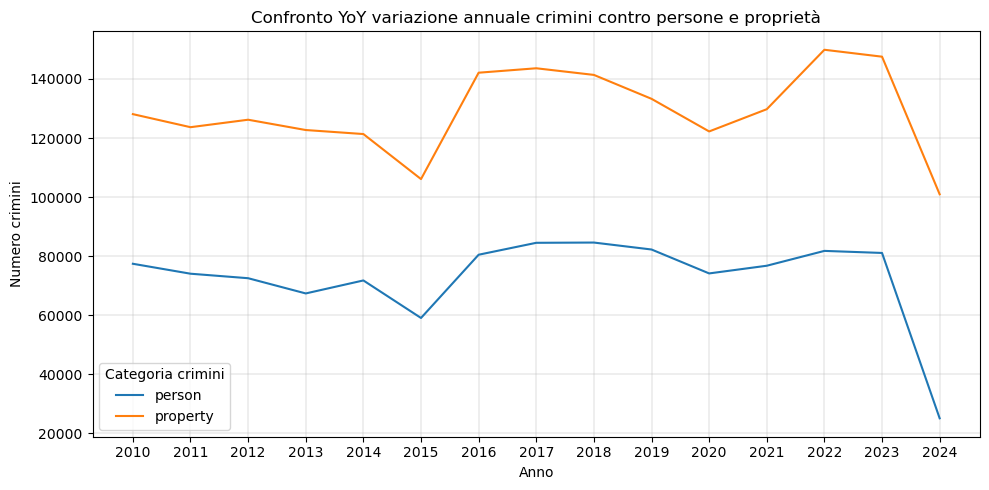

In [8]:
fig = plt.subplots(figsize=(10, 5))
ax = sns.lineplot(
    x=person_vs_property_yearly_df['year'],
    y=person_vs_property_yearly_df['count'],
    hue=person_vs_property_yearly_df['crime_category']
)

ax.legend(
    title = 'Categoria crimini',
    loc = 3,
)
plt.title ('Confronto YoY variazione annuale crimini contro persone e proprietà')
plt.xlabel('Anno')
plt.ylabel('Numero crimini')
plt.grid(
    linewidth = 0.3
)
plt.xticks(range(2010, 2025))

plt.savefig('../../outputs/Confronto_YoY_variazione_annuale_crimini_contro persone_e_proprietà.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

### Osservazioni Q1.2

- **Property domina costantemente**: i crimini contro la proprietà rappresentano 
  circa il 63% del totale, con volumi quasi doppi rispetto a quelli contro la persona.

- **Entrambe le categorie seguono gli stessi cicli** (calo 2010-2015, risalita 
  2015-2017, calo 2020, risalita 2021-2022) ma con intensità molto diverse.

- **Calo 2015**: Person crolla del -17.7% (da 71.779 a 59.075), Property del 
  -12.6% (da 121.343 a 106.094). Il calo è più marcato nei crimini contro la 
  persona, probabilmente amplificato dall'anomalia classificatoria di quell'anno.

- **Calo 2020 (COVID)**: Property cala del -8.3% (da 133.268 a 122.225), Person 
  del -9.8% (da 82.254 a 74.156). Entrambe calano in modo simile, ma nel biennio 
  successivo Property risale più velocemente: +22.6% dal 2020 al 2022 (da 122.225 
  a 149.876) contro +10.3% di Person (da 74.156 a 81.784).

- **Picco 2022**: Property raggiunge il massimo assoluto del dataset (149.876), 
  superando i livelli pre-COVID. Person (81.784) resta sotto il picco del 
  2017-2018 (~84.600).

- **2024**: crollo drastico su entrambe (-69.1% Person, -31.6% Property rispetto 
  al 2023). Da interpretare con cautela per le ragioni documentate nella Q1.1 
  (dataset congelato a giugno 2025, crimini denunciati in ritardo non inclusi).

- **Insight per lo stakeholder**: la criminalità contro la proprietà è più volatile 
  e reattiva agli eventi esterni, mentre quella contro la persona è più stabile e 
  strutturale. Implicazione: le strategie per i crimini contro la proprietà possono 
  essere tattiche e reattive, quelle contro la persona richiedono interventi 
  strutturali e di lungo periodo.

## 4. Q1.3 — Categorie con maggior crescita e decrescita YoY

Identifichiamo le categorie di reato con la maggior variazione percentuale 
anno su anno negli ultimi anni del dataset. Obiettivo: individuare reati 
emergenti (in crescita) e reati in calo, segnalando potenziali shift nelle 
priorità operative.

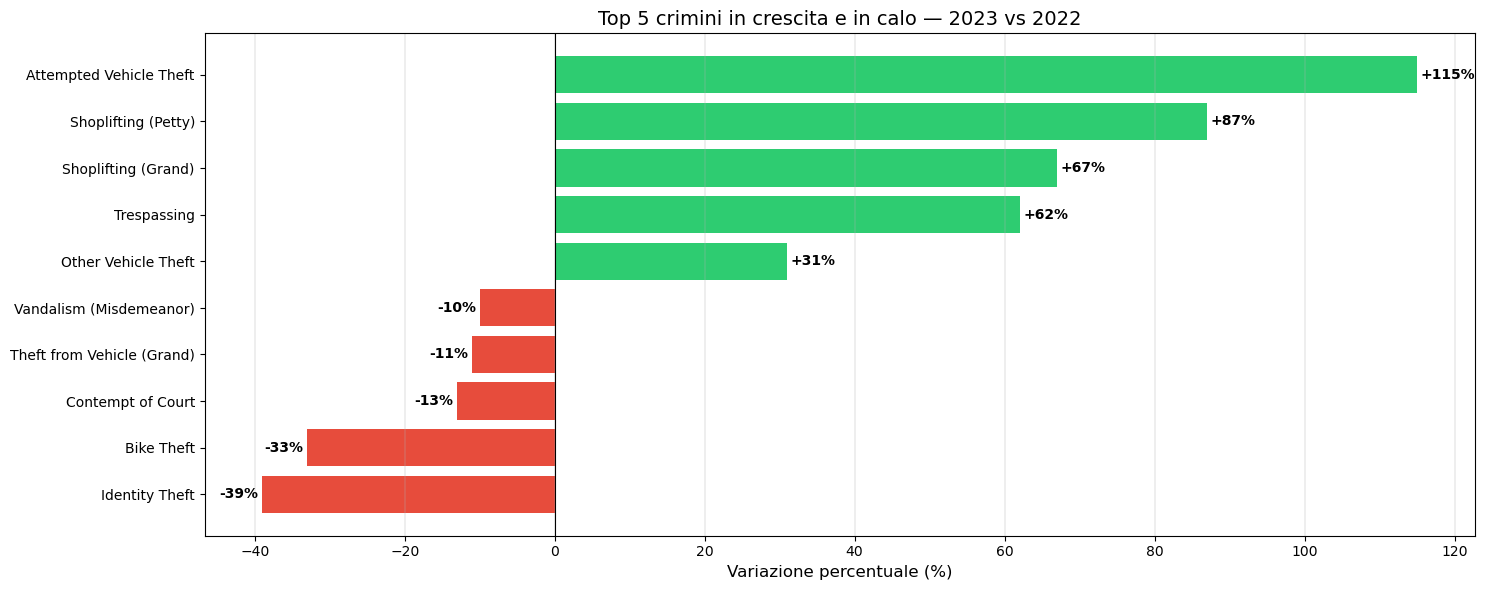

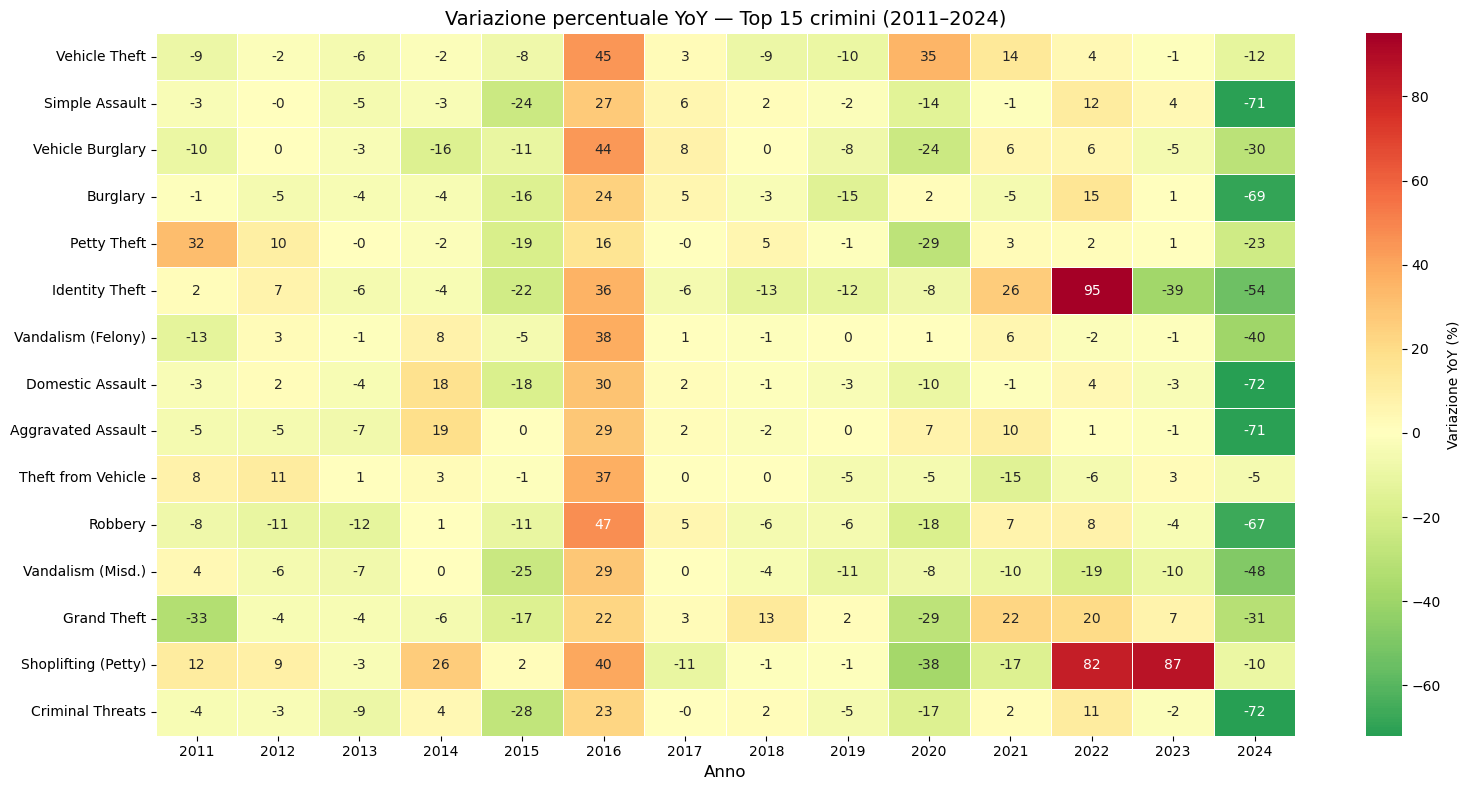

In [9]:
# --- Step 1: Preparazione dati ---
variationYoY_category_df = df[['year', 'Crm Cd Desc']]
variationYoY_category_df = (
    variationYoY_category_df
        .groupby(['year', 'Crm Cd Desc'])
        .agg(count=('Crm Cd Desc', 'count'))
        .reset_index()
)
 
variation_pivot_df = variationYoY_category_df.pivot(
    index='year',
    columns='Crm Cd Desc',
    values='count'
)
 
# Filtro: solo crimini con >= 500 occorrenze nel 2022
filter_mask = variation_pivot_df.loc[2022] >= 500
filtered_pivot = variation_pivot_df.loc[:, filter_mask]
 
# Variazione percentuale YoY
variation = filtered_pivot.pct_change(fill_method=None).round(2)
 
# --- Step 2: Bar chart — Snapshot 2023 ---
top5 = variation.loc[2023].nlargest(5)
bottom5 = variation.loc[2023].nsmallest(5)
concat_variation = pd.concat([top5, bottom5]).sort_values(ascending=True)
 
# Nomi abbreviati per leggibilità
short_names_q13 = {
    'VEHICLE - ATTEMPT STOLEN': 'Attempted Vehicle Theft',
    'SHOPLIFTING - PETTY THEFT ($950 & UNDER)': 'Shoplifting (Petty)',
    'SHOPLIFTING-GRAND THEFT ($950.01 & OVER)': 'Shoplifting (Grand)',
    'TRESPASSING': 'Trespassing',
    'VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, BIKES, ETC)': 'Other Vehicle Theft',
    'THEFT OF IDENTITY': 'Identity Theft',
    'BIKE - STOLEN': 'Bike Theft',
    'CONTEMPT OF COURT': 'Contempt of Court',
    'THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND OVER)': 'Theft from Vehicle (Grand)',
    'VANDALISM - MISDEAMEANOR ($399 OR UNDER)': 'Vandalism (Misdemeanor)'
}
 
concat_variation_short = concat_variation.rename(index=short_names_q13)
 
# Colori: verde per crescita, rosso per calo
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in concat_variation_short.values]
 
fig, ax = plt.subplots(figsize=(15, 6))
bars = ax.barh(concat_variation_short.index, concat_variation_short.values * 100, color=colors)
 
# Aggiunta etichette con il valore percentuale su ogni barra
for bar, val in zip(bars, concat_variation_short.values * 100):
    x_pos = bar.get_width()
    offset = 0.5 if x_pos >= 0 else -0.5
    ha = 'left' if x_pos >= 0 else 'right'
    ax.text(x_pos + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.0f}%', va='center', ha=ha, fontsize=10, fontweight='bold')
 
ax.set_xlabel('Variazione percentuale (%)', fontsize=12)
ax.set_ylabel('')
ax.set_title('Top 5 crimini in crescita e in calo — 2023 vs 2022', fontsize=14)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(axis='x', linewidth=0.3)
plt.tight_layout()
plt.savefig('../../outputs/variation_top5_bottom5_crimes_2023.png', dpi=150, bbox_inches='tight')
plt.show()
 
 
# --- Step 3: Heatmap — Contesto storico YoY ---
 
# Selezioniamo i 15 crimini più frequenti in assoluto per la heatmap
top15_crimes = df['Crm Cd Desc'].value_counts().head(15).index.tolist()
variation_top15 = variation[top15_crimes].iloc[1:]  # iloc[1:] per escludere il primo anno (NaN da pct_change)
 
# Nomi abbreviati per la heatmap
short_names_heatmap = {
    'VEHICLE - STOLEN': 'Vehicle Theft',
    'BATTERY - SIMPLE ASSAULT': 'Simple Assault',
    'BURGLARY FROM VEHICLE': 'Vehicle Burglary',
    'BURGLARY': 'Burglary',
    'THEFT PLAIN - PETTY ($950 & UNDER)': 'Petty Theft',
    'THEFT OF IDENTITY': 'Identity Theft',
    'VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS)': 'Vandalism (Felony)',
    'INTIMATE PARTNER - SIMPLE ASSAULT': 'Domestic Assault',
    'ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT': 'Aggravated Assault',
    'THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)': 'Theft from Vehicle',
    'ROBBERY': 'Robbery',
    'VANDALISM - MISDEAMEANOR ($399 OR UNDER)': 'Vandalism (Misd.)',
    'THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD': 'Grand Theft',
    'SHOPLIFTING - PETTY THEFT ($950 & UNDER)': 'Shoplifting (Petty)',
    'CRIMINAL THREATS - NO WEAPON DISPLAYED': 'Criminal Threats'
}
 
variation_top15 = variation_top15.rename(columns=short_names_heatmap)
 
# Convertiamo in percentuali per la visualizzazione
variation_top15_pct = variation_top15 * 100
 
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    variation_top15_pct.T,   # Trasposto: crimini sulle righe, anni sulle colonne
    cmap='RdYlGn_r',        # Rosso = crescita (male), Verde = calo (bene)
    center=0,
    annot=True,
    fmt='.0f',
    linewidths=0.5,
    cbar_kws={'label': 'Variazione YoY (%)'},
    ax=ax
)
ax.set_title('Variazione percentuale YoY — Top 15 crimini (2011–2024)', fontsize=14)
ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../../outputs/heatmap_yoy_variation_top15.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q1.3

I due grafici sono complementari e vanno letti insieme. Il grafico a barre 
mostra i top 5 crimini con la maggior variazione positiva e negativa tra il 
2022 e il 2023. La heatmap contestualizza questi dati in una prospettiva 
storica più ampia, mostrando la variazione percentuale YoY dei 15 crimini 
con maggior volume di occorrenze nel periodo 2011–2024.

**Biennio 2015–2016**: il pattern più evidente della heatmap. Nel 2015 si 
registra una tendenza generalizzata al calo su quasi tutte le categorie, con 
riduzioni particolarmente marcate per Criminal Threats (-28%), Simple Assault 
(-24%) e Vandalism Misdemeanor (-25%). Il 2016 inverte bruscamente questa 
tendenza con aumenti significativi su tutti i crimini, nessuno escluso. La 
rapidità e l'uniformità di questo rimbalzo suggerisce un possibile effetto 
di natura classificatoria o normativa piuttosto che un reale peggioramento 
della criminalità — un'ipotesi che meriterebbe approfondimento con fonti 
esterne nella relazione finale.

**2020 — Effetto COVID**: tendenza generalizzata alla decrescita, coerente con 
le restrizioni legate al COVID-19 e la conseguente riduzione della mobilità 
urbana. Fa eccezione il furto di veicoli, che registra un aumento del +35%. 
Questo dato, apparentemente controintuitivo, è probabilmente correlato alle 
restrizioni stesse: le strade più deserte e i veicoli fermi per periodi 
prolungati possono aver facilitato questo tipo di reato. Il fenomeno è stato 
documentato a livello nazionale (report FBI UCR, dati NICB) e non è specifico 
di Los Angeles. La causalità diretta col COVID non è dimostrabile con questi 
dati, ma la correlazione temporale è chiara.

**2022 — Anomalie Identity Theft e Shoplifting**: emergono due valori 
nettamente fuori scala. L'Identity Theft registra un aumento del +95% e lo 
Shoplifting (Petty) dell'+82%. Nel 2023 i due crimini seguono però traiettorie 
opposte: l'Identity Theft si normalizza con un calo del -39%, suggerendo un 
fenomeno temporaneo probabilmente legato alla digitalizzazione accelerata 
post-pandemia; lo Shoplifting (Petty) continua invece ad accelerare con un 
ulteriore +87%, come confermato dal grafico a barre, segnalando una tendenza 
strutturale che non accenna a rientrare.

**Nota sul 2024**: la colonna 2024 nella heatmap mostra cali generalizzati su 
tutti i crimini. Come documentato nella Q1.1, il dataset 2024 è potenzialmente 
incompleto (crimini denunciati dopo giugno 2025 non inclusi). Le variazioni 
del 2024 non vanno interpretate come trend reali.

**Nota metodologica**: per il bar chart sono stati filtrati solo i crimini con 
almeno 500 occorrenze nel 2022, per evitare che variazioni percentuali 
elevate su volumi irrilevanti (es. +1900% su un crimine con 1 caso) 
distorcano i risultati.

## 5. Q1.4 — Pattern stagionali

Analizziamo la distribuzione mensile dei crimini per verificare l'esistenza 
di pattern stagionali. Confrontiamo crimini contro la persona e contro la 
proprietà per capire se le due categorie seguono cicli stagionali diversi, 
e approfondiamo su tipologie specifiche (es. furti residenziali vs furti 
di veicoli).

**Domanda**: esistono pattern stagionali statisticamente evidenti? Come si 
differenziano tra macro-categorie e tipologie specifiche di reato?

In [10]:
season_pattern_df = (
    df
    .groupby(['year', 'month', 'crime_category'], as_index = False)
    .agg(count=('crime_category', 'count'))
)

season_pattern_df = season_pattern_df[season_pattern_df['crime_category'] != 'other']

print(season_pattern_df.head(15))

    year  month crime_category  count
1   2010      1         person   6970
2   2010      1       property  12193
4   2010      2         person   5836
5   2010      2       property   9874
7   2010      3         person   6677
8   2010      3       property  11087
10  2010      4         person   6512
11  2010      4       property  10922
13  2010      5         person   6864
14  2010      5       property  10503
16  2010      6         person   6970
17  2010      6       property  10418
19  2010      7         person   6793
20  2010      7       property  10765
22  2010      8         person   6528


In [11]:
groupped_season_pattern_df = (
    season_pattern_df
    .groupby(['month', 'crime_category'], as_index=False)
    .agg(mean=('count', 'mean'))
)

print(groupped_season_pattern_df.head(12))

    month crime_category          mean
0       1         person   6296.666667
1       1       property  11635.866667
2       2         person   5595.466667
3       2       property  10208.933333
4       3         person   6202.933333
5       3       property  10928.200000
6       4         person   6058.733333
7       4       property  10548.000000
8       5         person   6263.400000
9       5       property  10788.933333
10      6         person   6187.733333
11      6       property  10574.933333


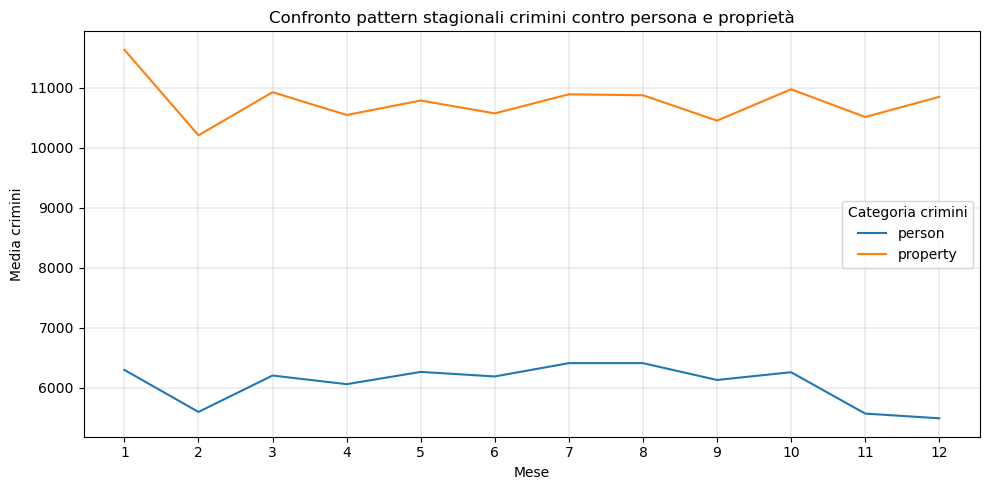

In [12]:
fig = plt.subplots(figsize = (10, 5))

ax = sns.lineplot(
    groupped_season_pattern_df,
    x = groupped_season_pattern_df['month'],
    y = groupped_season_pattern_df['mean'],
    hue = groupped_season_pattern_df['crime_category']
)

ax.legend(
    title = 'Categoria crimini'
)
plt.title ('Confronto pattern stagionali crimini contro persona e proprietà')
plt.xlabel('Mese')
plt.ylabel('Media crimini')
plt.grid(
    linewidth = 0.3
)
plt.xticks(range(1, 13))

plt.tight_layout()
plt.savefig('../../outputs/Confronto_pattern_stagionali_crimini_contro_persona_e_proprietà.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q1.4 — Parte 1: Macro-categorie

- **Minimo condiviso a febbraio**: entrambe le categorie raggiungono il punto 
  più basso a febbraio, il mese più corto e con mobilità urbana ridotta per 
  ragioni climatiche.

- **Divergenza a dicembre**: i crimini contro la persona continuano a calare, 
  mentre quelli contro la proprietà mostrano una leggera risalita. Andamento 
  probabilmente riconducibile ai furti legati al periodo natalizio — abitazioni 
  incustodite, maggiore presenza di beni nelle auto e nei negozi affollati — 
  fenomeni che impattano la proprietà senza necessariamente coinvolgere la 
  persona.

- **Diversa ampiezza di variazione**: i crimini contro la proprietà oscillano 
  in un range più ampio (circa 10.200–11.500), mentre quelli contro la persona 
  restano in un intervallo più stretto (circa 5.700–6.400). I crimini contro 
  la proprietà risultano più sensibili ai fattori stagionali, mentre quelli 
  contro la persona hanno un carattere più strutturale e distribuito 
  uniformemente nell'anno.

- **Picchi Property a marzo e ottobre**: i crimini contro la proprietà mostrano 
  i valori più alti in marzo e ottobre, un pattern controintuitivo rispetto 
  all'aspettativa classica del picco estivo. Potrebbe meritare un 
  approfondimento sui crimini specifici che guidano questi picchi nella 
  seconda parte dell'analisi stagionale.

### Q1.4 — Parte 2: Approfondimento stagionale crimini Property

I crimini contro la proprietà mostrano picchi a marzo e ottobre, un pattern 
controintuitivo. Approfondiamo analizzando i top 5 crimini Property 
singolarmente per identificare quali tipologie guidano quei picchi.

In [13]:
df.head()

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


In [14]:
top5_property = df[df['crime_category'] == 'property']['Crm Cd Desc'].value_counts().head(5).index.tolist()
top5_property

['VEHICLE - STOLEN',
 'BURGLARY FROM VEHICLE',
 'BURGLARY',
 'THEFT PLAIN - PETTY ($950 & UNDER)',
 'THEFT OF IDENTITY']

In [15]:
propertyFocus_df = (
    df
    .groupby(['Crm Cd Desc', 'year', 'month', 'crime_category'], as_index = False)
    .agg(count=('Crm Cd Desc', 'count'))
)

propertyFocus_df=propertyFocus_df[propertyFocus_df['crime_category'] == 'property']
propertyFocus_df['crime_category'].value_counts()

propertyFocus_df = (
    propertyFocus_df
    .groupby(['Crm Cd Desc', 'month'], as_index = False)
    .agg(mean = ('count', 'mean')).round(2)
)

top5property_filter = propertyFocus_df['Crm Cd Desc'].isin(top5_property)

filteredProperty_df = propertyFocus_df[top5property_filter].copy()

print(filteredProperty_df['Crm Cd Desc'].nunique())
print('==============')
print(filteredProperty_df['Crm Cd Desc'].unique())


5
['BURGLARY' 'BURGLARY FROM VEHICLE' 'THEFT OF IDENTITY'
 'THEFT PLAIN - PETTY ($950 & UNDER)' 'VEHICLE - STOLEN']


In [16]:
filteredProperty_df.head()

,Crm Cd Desc,month,mean
96,BURGLARY,1,1224.53
97,BURGLARY,2,1068.53
98,BURGLARY,3,1139.60
99,BURGLARY,4,1084.20
100,BURGLARY,5,1141.33


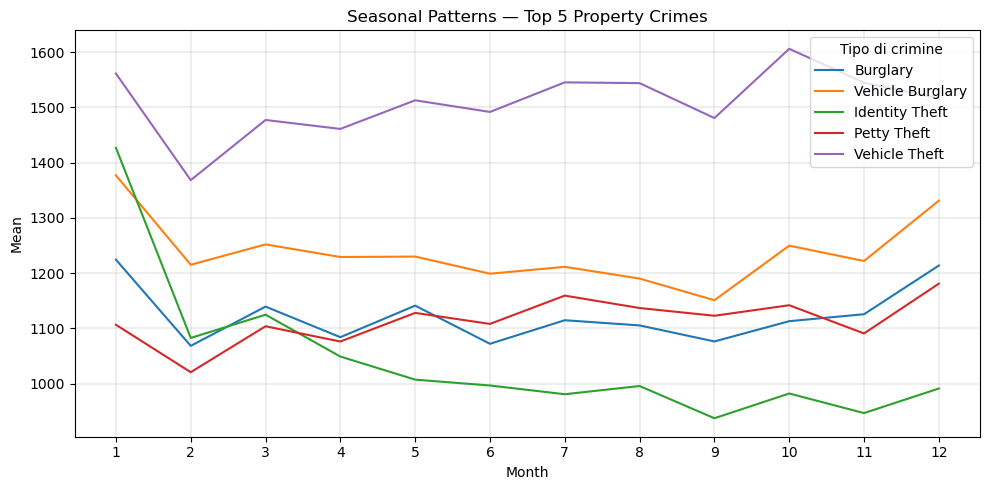

In [17]:
short_names2 = {
    'VEHICLE - STOLEN': 'Vehicle Theft',
    'THEFT OF IDENTITY': 'Identity Theft',
    'BURGLARY FROM VEHICLE': 'Vehicle Burglary',
    'BURGLARY': 'Burglary',
    'THEFT PLAIN - PETTY ($950 & UNDER)': 'Petty Theft'
}

filteredProperty_df['crime_short'] = filteredProperty_df['Crm Cd Desc'].map(short_names2)

fig = plt.subplots(figsize=(10,5))
sns.lineplot(
    x = filteredProperty_df['month'],
    y = filteredProperty_df['mean'],
    hue = filteredProperty_df['crime_short']
)

plt.legend(title='Tipo di crimine')
plt.title('Seasonal Patterns — Top 5 Property Crimes')
plt.xlabel('Month')
plt.ylabel('Mean')
plt.grid(
    linewidth = 0.3
)
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig('../../outputs/seasonal-patterns-top5-property-crimes.png', dpi=150, bbox_inches='tight')
plt.show()

### Osservazioni Q1.4 — Parte 2: Approfondimento crimini Property

**Vehicle Theft — crimine dominante**: è il principale responsabile del picco 
di ottobre osservato nella Parte 1. Mostra un pattern stagionale chiaro e 
pronunciato: picco a gennaio, crollo a febbraio, risalita graduale con un 
secondo massimo netto a ottobre. È l'unico crimine del gruppo con una 
stagionalità così regolare e riconoscibile.

**Il picco di marzo è un effetto aggregato**: non è attribuibile a un singolo 
crimine. Dopo il minimo condiviso di febbraio, tutti i crimini rimbalzano 
contemporaneamente a marzo, generando un picco aggregato che non emerge con 
la stessa chiarezza nell'analisi per crimine singolo.

**Identity Theft — pattern inverso**: mostra la stagionalità più anomala del 
gruppo. Parte da valori alti a gennaio, crolla progressivamente fino al minimo 
di settembre, poi risale leggermente. È l'unico crimine con andamento 
marcatamente inverso rispetto agli altri, concentrandosi nei mesi invernali. 
Ipotesi: potrebbe essere collegato ai periodi di maggiore attività online 
(acquisti natalizi, dichiarazioni fiscali di inizio anno). Da verificare con 
fonti esterne nella relazione finale.

**Dicembre — divergenza Vehicle Theft**: a dicembre tutti i crimini Property 
aumentano tranne Vehicle Theft, che scende. Furti in abitazione, furti da 
veicolo e piccoli furti salgono per ragioni legate al periodo natalizio 
(beni incustoditi, negozi affollati, abitazioni vuote). Il furto di veicoli 
segue la direzione opposta: a dicembre le persone usano meno l'auto, la 
parcheggiano in luoghi più sorvegliati e prestano maggiore attenzione.

**Vehicle Burglary, Burglary e Petty Theft**: Vehicle Burglary mantiene un 
andamento piatto per la maggior parte dell'anno con un'impennata a dicembre. 
Burglary e Petty Theft si muovono in modo molto simile tra loro, senza picchi 
stagionali evidenti, confermando il loro carattere strutturale e distribuito 
uniformemente nell'anno.

## 6. Q1.5 — Fasce orarie e giorni della settimana

Analizziamo la distribuzione dei crimini per fascia oraria e giorno della 
settimana, stratificando per macro-categoria (Person vs Property). 
Obiettivo: identificare le finestre temporali più critiche e capire se 
i pattern differiscono tra le due categorie.

**Nota metodologica**: i record con `hour_occ = 0` (mezzanotte) includono 
un artefatto di registrazione — crimini con orario sconosciuto codificati 
come 0000. Questo genera un picco artificiale sulla fascia "Night" che va 
tenuto presente nell'interpretazione.

**Domanda**: in quali fasce orarie e giorni della settimana si concentrano 
i crimini? I pattern differiscono tra crimini contro la persona e contro 
la proprietà?

In [18]:
hour_distribution_df = (
    df
    .groupby(['hour_bins', 'day_of_week', 'crime_category'], as_index = False, observed = True)
    .agg(counts=('crime_category', 'count'))
).copy()

print(hour_distribution_df.head())

  hour_bins day_of_week crime_category  counts
0     Night      Friday          other     829
1     Night      Friday         person   18027
2     Night      Friday       property   28452
3     Night      Monday          other     938
4     Night      Monday         person   18696


In [22]:
print(f'I valori unici di HOUR BINS sono: {hour_distribution_df['hour_bins'].nunique()}')
print(f'e sono: {hour_distribution_df['hour_bins'].unique()}')
print("==============================================================")
print(f'I valori unici di DAY OF WEEK sono: {hour_distribution_df['day_of_week'].nunique()}')
print(f'e sono: {hour_distribution_df['day_of_week'].unique()}')

I valori unici di HOUR BINS sono: 6
e sono: ['Night', 'Early Morning', 'Morning', 'Afternoon', 'Evening', 'Late Night']
Categories (6, object): ['Night' < 'Early Morning' < 'Morning' < 'Afternoon' < 'Evening' < 'Late Night']
I valori unici di DAY OF WEEK sono: 7
e sono: ['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday' 'Tuesday' 'Wednesday']


In [24]:
hour_distribution_df = hour_distribution_df[hour_distribution_df['crime_category'] != 'other']

giorni_ordinati = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hour_distribution_df['day_of_week'] = pd.Categorical(hour_distribution_df['day_of_week'], categories=giorni_ordinati, ordered=True)
hour_distribution_df = hour_distribution_df.sort_values('day_of_week')

print(hour_distribution_df.head())

    hour_bins day_of_week crime_category  counts
46    Morning      Monday         person   25098
67  Afternoon      Monday         person   32825
4       Night      Monday         person   18696
5       Night      Monday       property   27763
68  Afternoon      Monday       property   64281


In [28]:
person_pivot = hour_distribution_df[hour_distribution_df['crime_category'] == 'person'].pivot(
    columns = 'day_of_week',
    index = 'hour_bins',
    values = 'counts'
)

property_pivot = hour_distribution_df[hour_distribution_df['crime_category'] == 'property'].pivot(
    columns = 'day_of_week',
    index = 'hour_bins',
    values = 'counts'
)

print(person_pivot.head())
print('======================')
print(property_pivot.head())

day_of_week    Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
hour_bins                                                                    
Night           18696    15175      15406     15520   18027     28763   34062
Early Morning   10833     9941      10110     10219   10636     11192   12112
Morning         25098    24345      24964     24285   24689     23213   22428
Afternoon       32825    33077      33368     32357   33844     31611   31625
Evening         33924    33161      33411     33091   35307     33138   35149
day_of_week    Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
hour_bins                                                                    
Night           27763    25511      25635     26078   28452     32542   33902
Early Morning   22702    21828      22312     22695   22655     19681   18268
Morning         49042    48478      48742     47789   50727     40701   35542
Afternoon       64281    63088      64578     63368   70800     

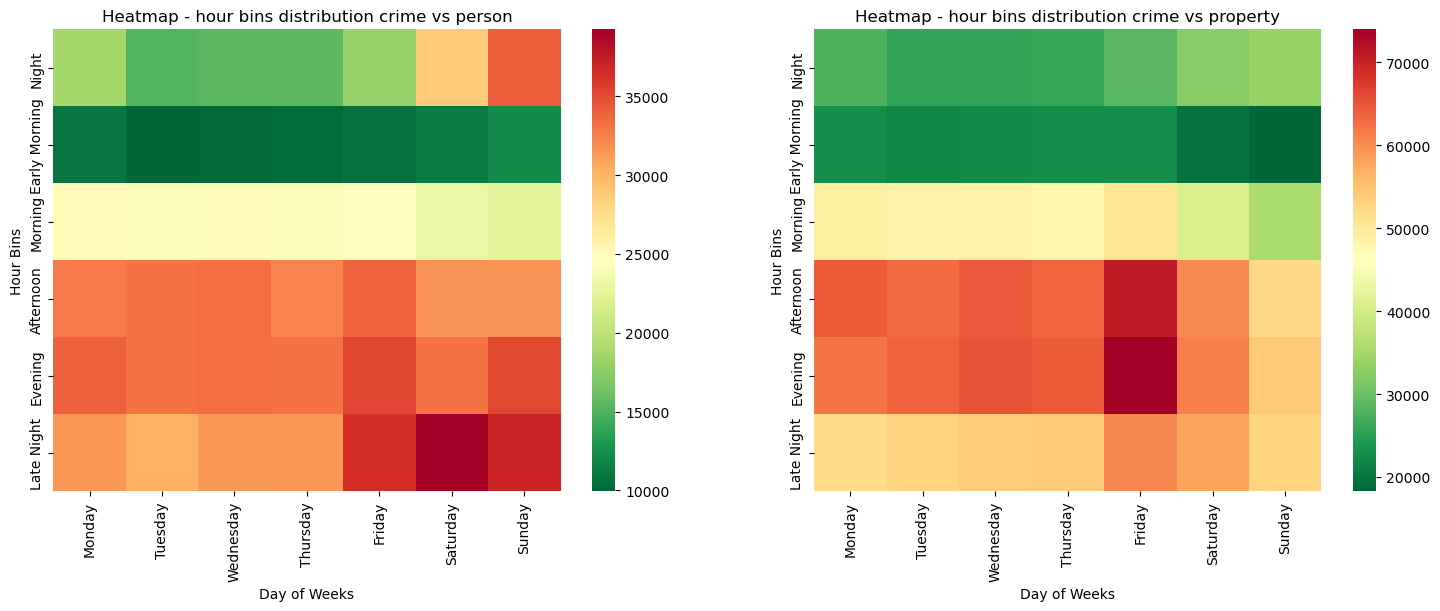

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(person_pivot, ax=ax1, cmap='RdYlGn_r')
sns.heatmap(property_pivot, ax=ax2, cmap='RdYlGn_r')

ax1.set_title('Heatmap - hour bins distribution crime vs person')
ax2.set_title('Heatmap - hour bins distribution crime vs property')

ax1.set_xlabel('Day of Weeks')
ax1.set_ylabel('Hour Bins')

ax2.set_xlabel('Day of Weeks')
ax2.set_ylabel('Hour Bins')

plt.show()
    
    